In [9]:
import pandas as pd
import numpy as np

# 1. Load data
df_all = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')
df_all['Timestamp'] = pd.to_datetime(df_all['Timestamp'])
df_all = df_all.sort_values(by=['Id', 'Timestamp']).reset_index(drop=True)

print("Starting extraction of Time-Varying (Start-Stop-Event) dataset...")

EVENT_THRESHOLD = 125
survival_records = []

# 2. Iterate through each user
for user_id, group in df_all.groupby('Id'):
    group = group.reset_index(drop=True)
    
    # 3. REUSE KEY IDEA: "Episode" logic (split if gap > 30 minutes)
    group['Time_Diff'] = group['Timestamp'].diff()
    group['New_Episode'] = (group['Time_Diff'] > pd.Timedelta(minutes=30)).astype(int)
    group['Episode_ID'] = group['New_Episode'].cumsum()
    
    # 4. Process each episode
    for ep_id, ep_group in group.groupby('Episode_ID'):
        ep_group = ep_group.sort_values('Timestamp').reset_index(drop=True)
        
        # Skip very short episodes (< 30 minutes → rolling window not meaningful)
        if len(ep_group) < 30:
            continue
            
        # 5. KEY IMPROVEMENT: Rolling Average (30-minute moving window)
        # Instead of averaging over the entire episode, use a rolling window
        ep_group['Rolling_Steps'] = ep_group['Steps'].rolling(window=30, min_periods=1).mean()
        ep_group['Rolling_Intensity'] = ep_group['Intensity'].rolling(window=30, min_periods=1).mean()
        
        # Compute relative duration within episode (in minutes)
        ep_group['duration_minutes'] = (
            ep_group['Timestamp'] - ep_group['Timestamp'].min()
        ).dt.total_seconds() / 60
        
        # 6. TIME-VARYING FORMAT (Start - Stop - Event)
        event_rows = ep_group[ep_group['Heart_Rate'] >= EVENT_THRESHOLD]
        
        if len(event_rows) > 0:
            # If threshold is reached → truncate at event time
            event_time = event_rows['duration_minutes'].iloc[0]
            user_data = ep_group[ep_group['duration_minutes'] <= event_time].copy()
            user_data['event'] = 0
            user_data.loc[user_data.index[-1], 'event'] = 1  # Event occurs at last row
        else:
            # Censored case: no event occurs
            user_data = ep_group.copy()
            user_data['event'] = 0
            
        # Create Start and Stop intervals
        user_data['start'] = user_data['duration_minutes'].shift(1).fillna(0)
        user_data['stop'] = user_data['duration_minutes']
        
        # Remove initial zero-length row
        user_data = user_data[user_data['start'] < user_data['stop']]
        
        # Create unique ID (User + Episode) for time-varying survival models
        user_data['Episode_Unique_ID'] = f"{user_id}_Ep{ep_id}"
        
        survival_records.append(user_data)

# 7. Combine and export
tv_survival_df = pd.concat(survival_records, ignore_index=True)

cols_order = [
    'Episode_Unique_ID', 'Id', 'start', 'stop', 'event',
    'Heart_Rate', 'Rolling_Steps', 'Rolling_Intensity', 'Timestamp'
]
tv_survival_df = tv_survival_df[cols_order]

output_file = 'Time_Varying_Survival_125BPM_W12.csv'
tv_survival_df.to_csv(output_file, index=False)

print(f"\n--- SURVIVAL DATA EXTRACTION REPORT ---")
print(f"Total valid episodes: {tv_survival_df['Episode_Unique_ID'].nunique()}")
print(f"Total exhaustion events (Event=1): {tv_survival_df['event'].sum()}")
print(f"File '{output_file}' is ready for time-varying Cox-PH modeling!")

Starting extraction of Time-Varying (Start-Stop-Event) dataset...

--- SURVIVAL DATA EXTRACTION REPORT ---
Total valid episodes: 120
Total exhaustion events (Event=1): 58
File 'Time_Varying_Survival_125BPM_W12.csv' is ready for time-varying Cox-PH modeling!


1. Training SARIMA(2,1,3)(1,0,1,96)...
-> Learned physiological inertia patterns successfully!
2. Activating Fast Rolling mechanism (no retraining)...
-> RMSE (Rolling 1-step): 12.02 BPM
-> MAE (Rolling 1-step): 6.08 BPM
-> Exported plot: Week12_SARIMA_Rolling_Plot.png
-> Exported file: Week12_SARIMA_Baseline_GoldenUser.csv (Input for Cox-PH model)


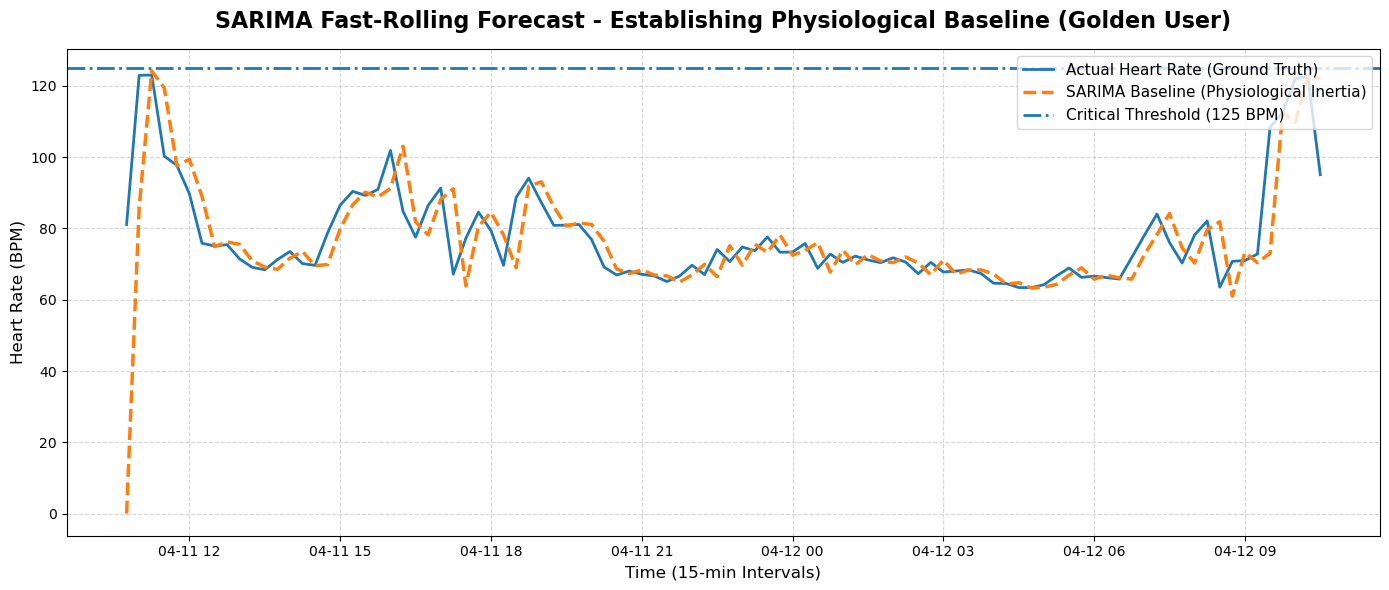

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# 1. Load data and select episode of the Golden User (ID: 6962181067)
df = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df_golden = df[df['Id'] == 6962181067].set_index('Timestamp')

# Resample to 15-minute intervals for consistency
df_resampled = df_golden.resample('15T').mean().interpolate(method='linear') \
                         .dropna(subset=['Heart_Rate'])

# Select the last 3 continuous days
train_size = 96 * 2  # 2 days for training
test_size = 96       # 1 day for testing (simulate real-time)
target_data = df_resampled.iloc[-train_size - test_size:]

train = target_data.iloc[:-test_size]
test = target_data.iloc[-test_size:]

# 2. OFFLINE TRAINING (Pure SARIMA - Physiological Engine)
print("1. Training SARIMA(2,1,3)(1,0,1,96)...")
# NOTE: exogenous variable (Steps) has been removed
model = SARIMAX(
    train['Heart_Rate'],
    order=(2, 1, 3),
    seasonal_order=(1, 0, 1, 96),
    enforce_stationarity=False,
    enforce_invertibility=False
)
res_train = model.fit(disp=False)
print("-> Learned physiological inertia patterns successfully!")

# 3. FAST ROLLING FORECAST (Zero-Latency Online Prediction)
print("2. Activating Fast Rolling mechanism (no retraining)...")
# NOTE: no exogenous input
# apply() automatically updates state using real observed HR values
res_rolling = res_train.apply(test['Heart_Rate'], refit=False)
predictions = res_rolling.fittedvalues[:len(test)]

# 4. Evaluation (Physiological baseline)
rmse = np.sqrt(mean_squared_error(test['Heart_Rate'], predictions))
mae = mean_absolute_error(test['Heart_Rate'], predictions)
print(f"-> RMSE (Rolling 1-step): {rmse:.2f} BPM")
print(f"-> MAE (Rolling 1-step): {mae:.2f} BPM")

# 5. Visualization (Week 12 report)
plt.figure(figsize=(14, 6))
plt.plot(test.index, test['Heart_Rate'], label='Actual Heart Rate (Ground Truth)', linewidth=2)
plt.plot(test.index, predictions, label='SARIMA Baseline (Physiological Inertia)', linestyle='--', linewidth=2.5)
plt.axhline(y=125, linestyle='-.', linewidth=2, label='Critical Threshold (125 BPM)')

plt.title('SARIMA Fast-Rolling Forecast - Establishing Physiological Baseline (Golden User)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Time (15-min Intervals)', fontsize=12)
plt.ylabel('Heart Rate (BPM)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('Week12_SARIMA_Rolling_Plot.png', dpi=300)
print("-> Exported plot: Week12_SARIMA_Rolling_Plot.png")

# 6. Export CSV for Week 15 scenario
# Combine predicted HR with REAL Steps (used later as simulation input)
test['SARIMA_Baseline_HR'] = predictions.values
test[['Heart_Rate', 'SARIMA_Baseline_HR', 'Steps']].to_csv(
    'Week12_SARIMA_Baseline_GoldenUser.csv'
)
print("-> Exported file: Week12_SARIMA_Baseline_GoldenUser.csv (Input for Cox-PH model)")

1. Plotting overall Kaplan-Meier survival curve...
-> Exported image: Week12_KaplanMeier_Teaser.png

2. Training Cox Time-Varying Proportional Hazards model...
Iteration 1: norm_delta = 3.77e-02, step_size = 0.9500, log_lik = -218.10943, newton_decrement = 5.45e+00, seconds_since_start = 0.2
Iteration 2: norm_delta = 1.82e-03, step_size = 0.9500, log_lik = -212.68293, newton_decrement = 1.28e-02, seconds_since_start = 0.2
Iteration 3: norm_delta = 9.10e-05, step_size = 0.9500, log_lik = -212.67020, newton_decrement = 3.18e-05, seconds_since_start = 0.3
Iteration 4: norm_delta = 4.79e-06, step_size = 1.0000, log_lik = -212.67017, newton_decrement = 7.95e-08, seconds_since_start = 0.3
Iteration 5: norm_delta = 1.16e-12, step_size = 1.0000, log_lik = -212.67017, newton_decrement = 4.70e-21, seconds_since_start = 0.3
Convergence completed after 5 iterations.

--- HAZARD RATIO SUMMARY ---


<lifelines.CoxTimeVaryingFitter: fitted with 67388 periods, 120 subjects, 58 events>
         event col = 'event'
         penalizer = 0.1
number of subjects = 120
 number of periods = 67388
  number of events = 58
partial log-likelihood = -212.67
  time fit was run = 2026-04-06 15:04:38 UTC

---
                   coef exp(coef)    p
covariate                             
Heart_Rate         0.00      1.00 0.01
Rolling_Steps      0.00      1.00 0.15
Rolling_Intensity  0.05      1.05 0.17
---
Partial AIC = 431.34
log-likelihood ratio test = 10.88 on 3 df
-log2(p) of ll-ratio test = 6.33


3. Running 'Scenario Scoring' test...

[RELATIVE RISK SCORING RESULTS]
- 0: Hazard Score = 1.03
- 1: Hazard Score = 1.37

-> COX-PH SYSTEM IS READY TO RECEIVE INPUT FROM SARIMA IN WEEK 15!


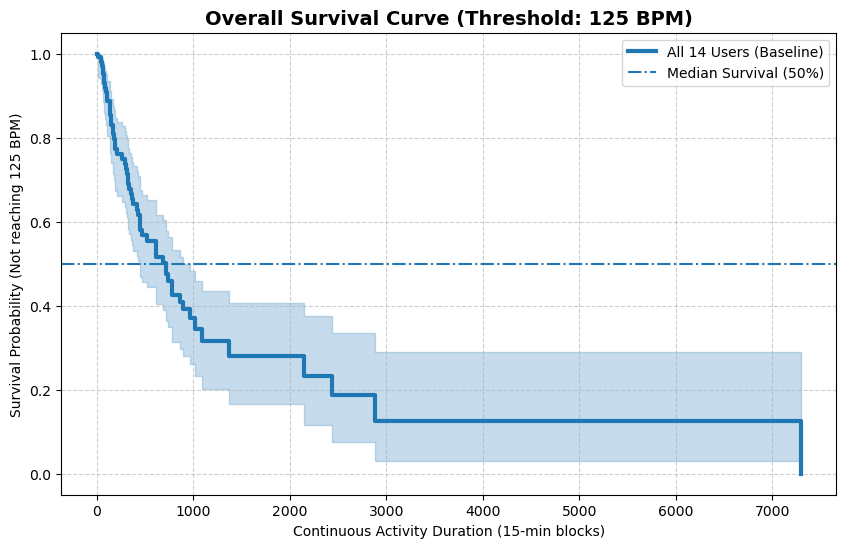

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxTimeVaryingFitter

# 1. LOAD TIME-VARYING DATA 
df_tv = pd.read_csv('../data/processed/Time_Varying_Survival_125BPM_W12.csv')

# --- TASK 3.1: PLOT "TEASER" KAPLAN-MEIER (OVERALL SURVIVAL) ---
print("1. Plotting overall Kaplan-Meier survival curve...")

# Convert Start-Stop format into (T, E) by taking the last record of each episode
summary_df = df_tv.groupby('Episode_Unique_ID').agg({
    'stop': 'max',
    'event': 'max'
})

kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

kmf.fit(
    summary_df['stop'],
    event_observed=summary_df['event'],
    label='All 14 Users (Baseline)'
)
kmf.plot_survival_function(linewidth=3)

plt.title('Overall Survival Curve (Threshold: 125 BPM)', fontsize=14, fontweight='bold')
plt.xlabel('Continuous Activity Duration (15-min blocks)')
plt.ylabel('Survival Probability (Not reaching 125 BPM)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=0.5, linestyle='-.', label='Median Survival (50%)')
plt.legend()

plt.savefig('Week12_KaplanMeier_Teaser.png', dpi=300)
print("-> Exported image: Week12_KaplanMeier_Teaser.png")


# --- TASK 3.2: TRAIN CAUSAL MODEL (COX TIME-VARYING) ---
print("\n2. Training Cox Time-Varying Proportional Hazards model...")

# Remove non-covariate columns to avoid errors
cols_to_drop = ['Id', 'Timestamp']
df_cox = df_tv.drop(columns=[col for col in cols_to_drop if col in df_tv.columns])

ctv = CoxTimeVaryingFitter(penalizer=0.1)  # Small regularization to prevent overfitting

ctv.fit(
    df_cox,
    id_col='Episode_Unique_ID',
    event_col='event',
    start_col='start',
    stop_col='stop',
    show_progress=True
)

print("\n--- HAZARD RATIO SUMMARY ---")
ctv.print_summary(columns=['coef', 'exp(coef)', 'p'])


# --- TASK 3.3: SCENARIO TESTING (Week 15 Feature Preview) ---
print("\n3. Running 'Scenario Scoring' test...")

# Define two hypothetical scenarios:
# Scenario 1: Light walking (baseline HR 80, low Steps, low Intensity)
# Scenario 2: Intense running (baseline HR 80, high Steps, high Intensity)
scenario_data = pd.DataFrame({
    'Heart_Rate': [80, 80],
    'Rolling_Steps': [10, 120],
    'Rolling_Intensity': [0.5, 2.5]
}, index=['Scenario 1 (Walking)', 'Scenario 2 (Running)'])

# Compute relative risk (Partial Hazard)
hazard_scores = ctv.predict_partial_hazard(scenario_data)

print("\n[RELATIVE RISK SCORING RESULTS]")
for idx, score in hazard_scores.items():
    print(f"- {idx}: Hazard Score = {score:.2f}")

print("\n-> COX-PH SYSTEM IS READY TO RECEIVE INPUT FROM SARIMA IN WEEK 15!")